<a href="https://colab.research.google.com/github/Niyathi189/finalyr-project/blob/main/finalyr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)


Epoch 1/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 305s 4s/step - accuracy: 0.4821 - loss: 0.8501 - val_accuracy: 0.5588 - val_loss: 0.6891
Epoch 2/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 193s 2s/step - accuracy: 0.5598 - loss: 0.6850 - val_accuracy: 0.5588 - val_loss: 0.6937
Epoch 3/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 189s 2s/step - accuracy: 0.5528 - loss: 0.6807 - val_accuracy: 0.5588 - val_loss: 0.6917
Epoch 4/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 190s 2s/step - accuracy: 0.5682 - loss: 0.6820 - val_accuracy: 0.5559 - val_loss: 0.6877
Epoch 5/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.5643 - loss: 0.6859 - val_accuracy: 0.5529 - val_loss: 0.6913
Epoch 6/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.5450 - loss: 0.6855 - val_accuracy: 0.5588 - val_loss: 0.6915
Epoch 7/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 192s 2s/step - accuracy: 0.5616 - loss: 0.6794 - val_accuracy: 0.5559 - val_loss: 0.7337
Epoch 8/15
85/85 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - accuracy: 0.5623 - loss: 0.6841 - val_accuracy: 0.5529 - v

In [ ]:
import os
import shutil
import pathlib
import random

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, initializers, regularizers

from tensorflow.keras.utils import image_dataset_from_directory

import matplotlib.pyplot as plt

import numpy as np
from tensorflow.keras.preprocessing.image import img_to_array, load_img
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import scipy.ndimage

from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image

from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications import VGG16

In [ ]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert (train_split + test_split + val_split) == 1
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    # Autotune all the 3 datasets
    train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
    return train_ds, val_ds, test_ds

In [ ]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

IMAGE_SIZE = 224  # or whatever size you want

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1./255)
])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
])


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import itertools
import cv2


In [ ]:
DATA_DIR = "/content/dataset"
IMAGE_SIZE = 224
BATCH_SIZE = 32
SEED = 123
EPOCHS = 15  # increase later if desired
AUTOTUNE = tf.data.AUTOTUNE


In [ ]:
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [ ]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf

DATA_DIR = "/content/dataset"
IMAGE_SIZE = 224
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# Load original datasets
train_raw = image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

val_raw = image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="binary",
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE
)

# ✔️ GET CLASS NAMES HERE
class_names = train_raw.class_names
print("Class Names:", class_names)

# Now optimize using prefetch
train_ds = train_raw.prefetch(buffer_size=AUTOTUNE)
val_ds = val_raw.prefetch(buffer_size=AUTOTUNE)


Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Class Names: ['cancer', 'normal']


In [ ]:
checkpoint_path = "/content/best_mobilenetv2.h5"
cb_early = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
cb_ckpt = callbacks.ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True, verbose=1)
cb_lr = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1)

# -----------------------
# Train (initial)
# -----------------------
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[cb_early, cb_ckpt, cb_lr],
    class_weight=class_weights
)


Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5959 - loss: 0.6861
Epoch 1: val_loss improved from inf to 0.40125, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 60s 2s/step - accuracy: 0.5982 - loss: 0.6833 - val_accuracy: 0.8200 - val_loss: 0.4012 - learning_rate: 1.0000e-04
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7677 - loss: 0.4901
Epoch 2: val_loss improved from 0.40125 to 0.34917, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 51s 2s/step - accuracy: 0.7678 - loss: 0.4895 - val_accuracy: 0.8500 - val_loss: 0.3492 - learning_rate: 1.0000e-04
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8253 - loss: 0.4017
Epoch 3: val_loss improved from 0.34917 to 0.33561, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8253 - loss: 0.4016 - val_accuracy: 0.8450 - val_loss: 0.3356 - learning_rate: 1.0000e-04
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8624 - loss: 0.3447
Epoch 4: val_loss improved from 0.33561 to 0.27080, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8618 - loss: 0.3453 - val_accuracy: 0.8750 - val_loss: 0.2708 - learning_rate: 1.0000e-04
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8513 - loss: 0.3154
Epoch 5: val_loss improved from 0.27080 to 0.26004, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8514 - loss: 0.3155 - val_accuracy: 0.8800 - val_loss: 0.2600 - learning_rate: 1.0000e-04
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8560 - loss: 0.3178
Epoch 6: val_loss improved from 0.26004 to 0.23915, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8565 - loss: 0.3173 - val_accuracy: 0.8950 - val_loss: 0.2392 - learning_rate: 1.0000e-04
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8909 - loss: 0.2744
Epoch 7: val_loss did not improve from 0.23915
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.8907 - loss: 0.2747 - val_accuracy: 0.8550 - val_loss: 0.3067 - learning_rate: 1.0000e-04
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8753 - loss: 0.2764
Epoch 8: val_loss did not improve from 0.23915
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8752 - loss: 0.2767 - val_accuracy: 0.8650 - val_loss: 0.2572 - learning_rate: 1.0000e-04
Epoch 9/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8895 - loss: 0.2533
Epoch 9: val_loss did not improve from 0.23915

Epoch 9: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.8897 - loss: 0.2532 - val_accuracy: 0.8750 - val_lo

25/25 ━━━━━━━━━━━━━━━━━━━━ 53s 2s/step - accuracy: 0.8972 - loss: 0.2432 - val_accuracy: 0.8800 - val_loss: 0.2228 - learning_rate: 5.0000e-05
Epoch 11/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9188 - loss: 0.2015
Epoch 11: val_loss did not improve from 0.22284
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9186 - loss: 0.2022 - val_accuracy: 0.8750 - val_loss: 0.2590 - learning_rate: 5.0000e-05
Epoch 12/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9281 - loss: 0.2218
Epoch 12: val_loss improved from 0.22284 to 0.19987, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9272 - loss: 0.2226 - val_accuracy: 0.9050 - val_loss: 0.1999 - learning_rate: 5.0000e-05
Epoch 13/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9041 - loss: 0.2388
Epoch 13: val_loss did not improve from 0.19987
25/25 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.9045 - loss: 0.2381 - val_accuracy: 0.8800 - val_loss: 0.2406 - learning_rate: 5.0000e-05
Epoch 14/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9204 - loss: 0.2094
Epoch 14: val_loss did not improve from 0.19987
25/25 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9200 - loss: 0.2101 - val_accuracy: 0.8950 - val_loss: 0.2350 - learning_rate: 5.0000e-05
Epoch 15/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9268 - loss: 0.1949
Epoch 15: val_loss did not improve from 0.19987

Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.9268 - loss: 0.1948 - val_accuracy: 0.8950 -

In [ ]:
base_model.trainable = True
fine_tune_at = 100  # freeze layers before this index
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=FINE_TUNE_EPOCHS,
    callbacks=[cb_early, cb_ckpt, cb_lr],
    class_weight=class_weights
)


Epoch 1/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7734 - loss: 0.4783
Epoch 1: val_loss improved from 0.19987 to 0.05492, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 90s 3s/step - accuracy: 0.7731 - loss: 0.4781 - val_accuracy: 0.9850 - val_loss: 0.0549 - learning_rate: 1.0000e-05
Epoch 2/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8528 - loss: 0.3675
Epoch 2: val_loss improved from 0.05492 to 0.02168, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.8524 - loss: 0.3672 - val_accuracy: 1.0000 - val_loss: 0.0217 - learning_rate: 1.0000e-05
Epoch 3/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8719 - loss: 0.3149
Epoch 3: val_loss improved from 0.02168 to 0.01101, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.8721 - loss: 0.3146 - val_accuracy: 1.0000 - val_loss: 0.0110 - learning_rate: 1.0000e-05
Epoch 4/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8934 - loss: 0.2834
Epoch 4: val_loss improved from 0.01101 to 0.00654, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.8938 - loss: 0.2831 - val_accuracy: 1.0000 - val_loss: 0.0065 - learning_rate: 1.0000e-05
Epoch 5/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9097 - loss: 0.2634
Epoch 5: val_loss improved from 0.00654 to 0.00410, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.9096 - loss: 0.2633 - val_accuracy: 1.0000 - val_loss: 0.0041 - learning_rate: 1.0000e-05
Epoch 6/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8701 - loss: 0.2946
Epoch 6: val_loss improved from 0.00410 to 0.00298, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.8711 - loss: 0.2928 - val_accuracy: 1.0000 - val_loss: 0.0030 - learning_rate: 1.0000e-05
Epoch 7/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9293 - loss: 0.1948
Epoch 7: val_loss improved from 0.00298 to 0.00219, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 75s 3s/step - accuracy: 0.9293 - loss: 0.1948 - val_accuracy: 1.0000 - val_loss: 0.0022 - learning_rate: 1.0000e-05
Epoch 8/8
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9204 - loss: 0.2202
Epoch 8: val_loss improved from 0.00219 to 0.00183, saving model to /content/best_mobilenetv2.h5


25/25 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.9205 - loss: 0.2196 - val_accuracy: 1.0000 - val_loss: 0.0018 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 8.


Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
Classes: ['cancer', 'normal']


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.5207 - loss: 0.8575 - val_accuracy: 0.5550 - val_loss: 0.6905
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5147 - loss: 0.7751 - val_accuracy: 0.6450 - val_loss: 0.6547
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 41s 2s/step - accuracy: 0.5605 - loss: 0.7406 - val_accuracy: 0.7000 - val_loss: 0.6302
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - accuracy: 0.5834 - loss: 0.6934 - val_accuracy: 0.7200 - val_loss: 0.6051
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6077 - loss: 0.6901 - val_accuracy: 0.7500 - val_loss: 0.5876
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.5989 - loss: 0.6832 - val_accuracy: 0.7250 - val_loss: 0.5685
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 44s 2s/step - accuracy: 0.6309 - loss: 0.6470 - val_accuracy: 0.7500 - val_loss: 0.5536
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6650 - loss: 0.6099 - val_accuracy: 0.7700 - val_loss:

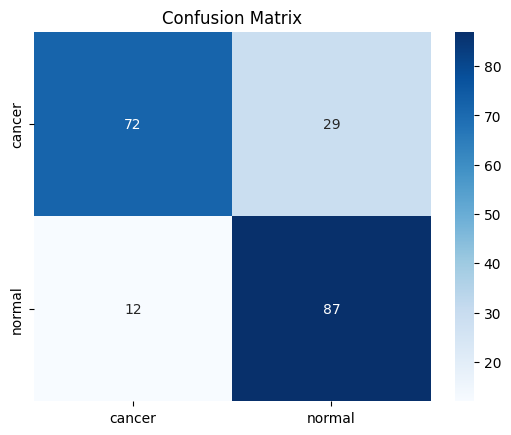

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------- Load Dataset --------------------
data_dir = "/content/dataset"

train_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

val_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# -------------------- CNN Model (Transfer Learning) --------------------
base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights="imagenet")
base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(optimizer=Adam(0.0001),
              loss="binary_crossentropy",
              metrics=["accuracy"])

model.summary()

# -------------------- Train Model --------------------
history = model.fit(train_ds, validation_data=val_ds, epochs=15)

# -------------------- Evaluate --------------------
y_true = np.array([], dtype=int)
y_pred = np.array([], dtype=int)

for imgs, labels in val_ds:
    predictions = (model.predict(imgs) > 0.5).astype("int32").flatten()
    y_pred = np.append(y_pred, predictions)
    y_true = np.append(y_true, labels.numpy().flatten())

print("\nAccuracy:", accuracy_score(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()


In [6]:
os.listdir('/content')

['.config', 'drive', 'sample_data']

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Copy of oral cancer.gdoc',
 'oral cancer.gdoc',
 'archive (3)',
 'archive',
 'archive (2)',
 'new_aug_dataset',
 'aanalum indha mayakkam.mp3',
 'unnai nenaikave.mp3',
 'pothavillaiye.mp3',
 'nenjukulle nee vizhundhai.mp3',
 'unna vida.mp3',
 'sundari kannal.mp3',
 'Standard recording 9.mp3',
 'kadhal kanave.mp3',
 'aathangakara marame.mp3',
 'vinmeen.mp3',
 'muthuchippi.mp3',
 'maya nadhi.mp3',
 'sotta sotta.mp3',
 'agastha.mp3',
 'rasave una nambi.mp3',
 'nenjukulla.mp3',
 'melliname.mp3',
 'nenjame.mp3',
 'nallai allai.mp3',
 'kodi aruvi.mp3',
 'ragasiyamai.mp3',
 'yaaro manathile.mp3',
 'Standard recording 2.mp3',
 'pirai thedum.mp3',
 'kangal edho.mp3',
 'Standard recording 7.mp3',
 'malare.mp3',
 'uyril thodum.mp3',
 'oru sanam.mp3',
 'sneham cherum neram.mp3',
 'Standard recording 3.mp3',
 'oru pathi kadhavu.mp3',
 'yennodu va va.mp3',
 'yeya en kottikara.mp3',
 'Saved from Chrome']

In [10]:
os.listdir('/content/drive/MyDrive/archive (3)')

['OralCancer']

In [16]:
import os
os.listdir('/content/drive/MyDrive/archive (3)/OralCancer')

['non-cancer', 'cancer']

In [19]:
print("Cancer folder files:")
print(os.listdir('/content/drive/MyDrive/archive (3)/OralCancer/cancer'))

print("\nNon-cancer folder files:")
print(os.listdir('/content/drive/MyDrive/archive (3)/OralCancer/non-cancer'))

Cancer folder files:
['dataset_Tongue-cancer-symptoms.png', 'f45634f6-0b4a-4d7d-ac44-5ea1658f728e.jpg', '1200px-ZungenCa2a.jpg', '01960a64-cfe8-444d-bbc5-575c15389a21.jpg', 'b2585c8d-65a0-4476-a4e6-a9f2d424cd60.jpg', 'pract_oral_cancer.jpg', 'dataset_SRMJResDentSci_2013_4_1_35_116830_u1.jpg', 'dataset_pract_oral_cancer.jpg', 'images (4).jpeg', 'd09a9b5c-a0b1-488f-9d50-2937fe578a7e.jpg', 'lip-reconstruction-gallery-skin-cancer-and-reconstructive-surgery-pertaining-to-lip-cancer-surgery.jpg', 'ds01089_im00213_c7_lipcancerpicturethu_jpg.jpg', 'C0235749-Mouth_cancer-SPL-20170511085515620.jpg', 'dataset_3-s2.0-B9780443100734500148-f10-07-9780443100734.jpg', 'Oral-cancer-Courtesy-of-Professor-Jan-Zapa1a-Chair-of-Cranio-Maxillofacial.png', 'figure1.jpg', 'oral-leukoplakia-br-image-credit-dermnet-new-zealand-br.jpg', 'mouth-cancer-symptoms-1.jpg', '41457tn.jpg', 'dataset_mouth-cancer-symptoms-1.jpg', 'first-sign-lip-cancer_c3094f88d448d26b.jpg', 'images (2).jpeg', 'skin-cancer-of-the-lip.jpg',

In [20]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive/OralCancer'):
    for file in files[:5]:  # show only first 5
        print(os.path.join(root, file))